In [7]:
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
import Utilities as utils
from qiskit.quantum_info import Statevector, partial_trace, state_fidelity


In [8]:
def encode(alpha, beta):
    qc = QuantumCircuit(9)
    # the Z phase flip layer - Outer layer
    qc.initialize([alpha, beta], 0)  # initialize first qubit to |ψ⟩
    qc.cx(0,3)
    qc.cx(0,6)
    qc.h([0, 3, 6])
    qc.barrier()

    # creating the inner block for bit flip now
    qc.cx(0,1); qc.cx(0,2)
    qc.cx(3,4); qc.cx(3,5)
    qc.cx(6,7); qc.cx(6,8)

    return qc

def syndrome_x_measurement(qc):
    # create the measurement syndrome
    a = QuantumRegister(6, 'a')
    c = ClassicalRegister(6, 'c')
    qc.add_register(a)
    qc.add_register(c)
    qc.barrier()
    # measure the bit flip error syndrome
    # block 0, q0, q1, q2 on a0 and a1
    qc.cx(0, a[0]); qc.cx(1,a[0])
    qc.cx(1, a[1]); qc.cx(2, a[1])
    qc.barrier()
    
    # block 1, q3, q4, q5 on a2 and a3
    qc.cx(3, a[2]); qc.cx(4,a[2])
    qc.cx(4, a[3]); qc.cx(5, a[3])
    qc.barrier()

    # block 2, q6, q7, q8 on a4 and a5
    qc.cx(6, a[4]); qc.cx(7,a[4])
    qc.cx(7, a[5]); qc.cx(8, a[5])
    qc.barrier()
    
    qc.measure(a, c)

    return qc

def syndrome_z_measurement(qc):
    a = QuantumRegister(2, 'za')
    c = ClassicalRegister(2, 'zc')
    qc.add_register(a)
    qc.add_register(c)
    qc.barrier()
    qc.h(a)
    # measure the phase flip error syndrome
    # measure block 0 vs block 1
    qc.cx(a[0],0); qc.cx(a[0], 1); qc.cx(a[0], 2)
    qc.cx(a[0], 3); qc.cx(a[0], 4); qc.cx(a[0], 5)
    qc.h(a[0])
    qc.barrier()

    # measure block 1 vs block 2
    qc.cx(a[1],3); qc.cx(a[1], 4); qc.cx(a[1], 5)
    qc.cx(a[1], 6); qc.cx(a[1], 7); qc.cx(a[1], 8)
    qc.h(a[1])
    qc.barrier()

    qc.measure(a, c)

    return qc

def inject_error(qc, block_num, position, error_type):
    # block_num: 0, 1, or 2
    # position: 0, 1, or 2 (within the block)
    # error_type: 'X' or 'Z'
    qubit_index = block_num * 3 + position
    if error_type == 'X':
        qc.x(qubit_index)
    elif error_type == 'Z':
        qc.z(qubit_index)
    elif error_type == 'Y':
        qc.y(qubit_index)
    else:       
        raise ValueError("error_type must be 'X', 'Y', or 'Z'")    

    return qc

def correct_error(qc, syndrome_string):
    # note qiskit is MSB first so so '000011' means a[5]a[4]a[3]a[2]a[1]a[0]
    # lets reverse it
    z_syndromes, x_syndromes = syndrome_string.split(' ')
    x_syndromes = x_syndromes[::-1] # reverse to match our indexing
    z_syndromes = z_syndromes[::-1] # reverse to match our indexing

    for block in range(3):
        # check for bit flip error in this block
        syndrome_x_output_by_block = x_syndromes[block*2: block*2+2]
        if syndrome_x_output_by_block == '11':  # error in middle qubit
            qc.x(block*3 + 1)
        elif syndrome_x_output_by_block == '10':  # error in first qubit
            qc.x(block*3)
        elif syndrome_x_output_by_block == '01':  # error in last qubit
            qc.x(block*3 + 2)

    # check for phase flip error between blocks
    if z_syndromes == '10':  # block 0 vs block 1 differ → error in block 1
        qc.z(0)
    elif z_syndromes == '11':  # block 0 vs block 1 differ and block 1 vs block 2 differ → error in block 1
        qc.z(3)  # correct block 1 representative
    elif z_syndromes == '01':  # block 1 vs block 2 differ → error in block 2
        qc.z(6)

    return qc


def run(alpha, beta, error_block=None, error_position=None, error_type=None):
    encoded_qc = encode(alpha, beta)
    initial_sv = Statevector(encoded_qc)
    error_qc = inject_error(encoded_qc, error_block, error_position, error_type) 
    xsyndromeqc = syndrome_x_measurement(error_qc)
    zsyndromeqc = syndrome_z_measurement(xsyndromeqc)
    display(zsyndromeqc.draw('mpl', style="Clifford"))

    sim = AerSimulator()
    counts = sim.run(zsyndromeqc, shots=1).result().get_counts()
    syndrome_string = list(counts.keys())[0]
    print(f"Syndrome for error type {error_type} at block {error_block}, position {error_position}, Got: {syndrome_string}")
    print_syndrome(syndrome_string)

    correctedqc = correct_error(zsyndromeqc, syndrome_string)
    # snapshot statevector before measurement
    correctedqc.save_statevector()

    # measureing the data states now
    # measure data qubits
    data = ClassicalRegister(9, 'data')
    correctedqc.add_register(data)
    correctedqc.measure(range(9), data)
    result = sim.run(correctedqc, shots=1024).result()
    full_sv = Statevector(result.get_statevector())
    data_state = partial_trace(full_sv, list(range(9, 17)))

    return initial_sv, data_state


def print_syndrome(syndrome_string):
    z_raw, x_raw = syndrome_string.split(' ')
    x_bits = x_raw[::-1]
    z_bits = z_raw[::-1]

    x_table = {'10': 'left qubit', '11': 'middle qubit', '01': 'right qubit', '00': 'no error'}
    z_table = {'10': 'block 0', '11': 'block 1', '01': 'block 2', '00': 'no error'}

    print(f"┌─────────┬────────┬──────────────┐")
    print(f"│ Block 0 │  {x_bits[0:2]}    │ {x_table[x_bits[0:2]]:12} │")
    print(f"│ Block 1 │  {x_bits[2:4]}    │ {x_table[x_bits[2:4]]:12} │")
    print(f"│ Block 2 │  {x_bits[4:6]}    │ {x_table[x_bits[4:6]]:12} │")
    print(f"│ Z parity│  {z_bits}    │ {z_table[z_bits]:12} │")
    print(f"└─────────┴────────┴──────────────┘")





──────────────────── X ERROR ────────────────────



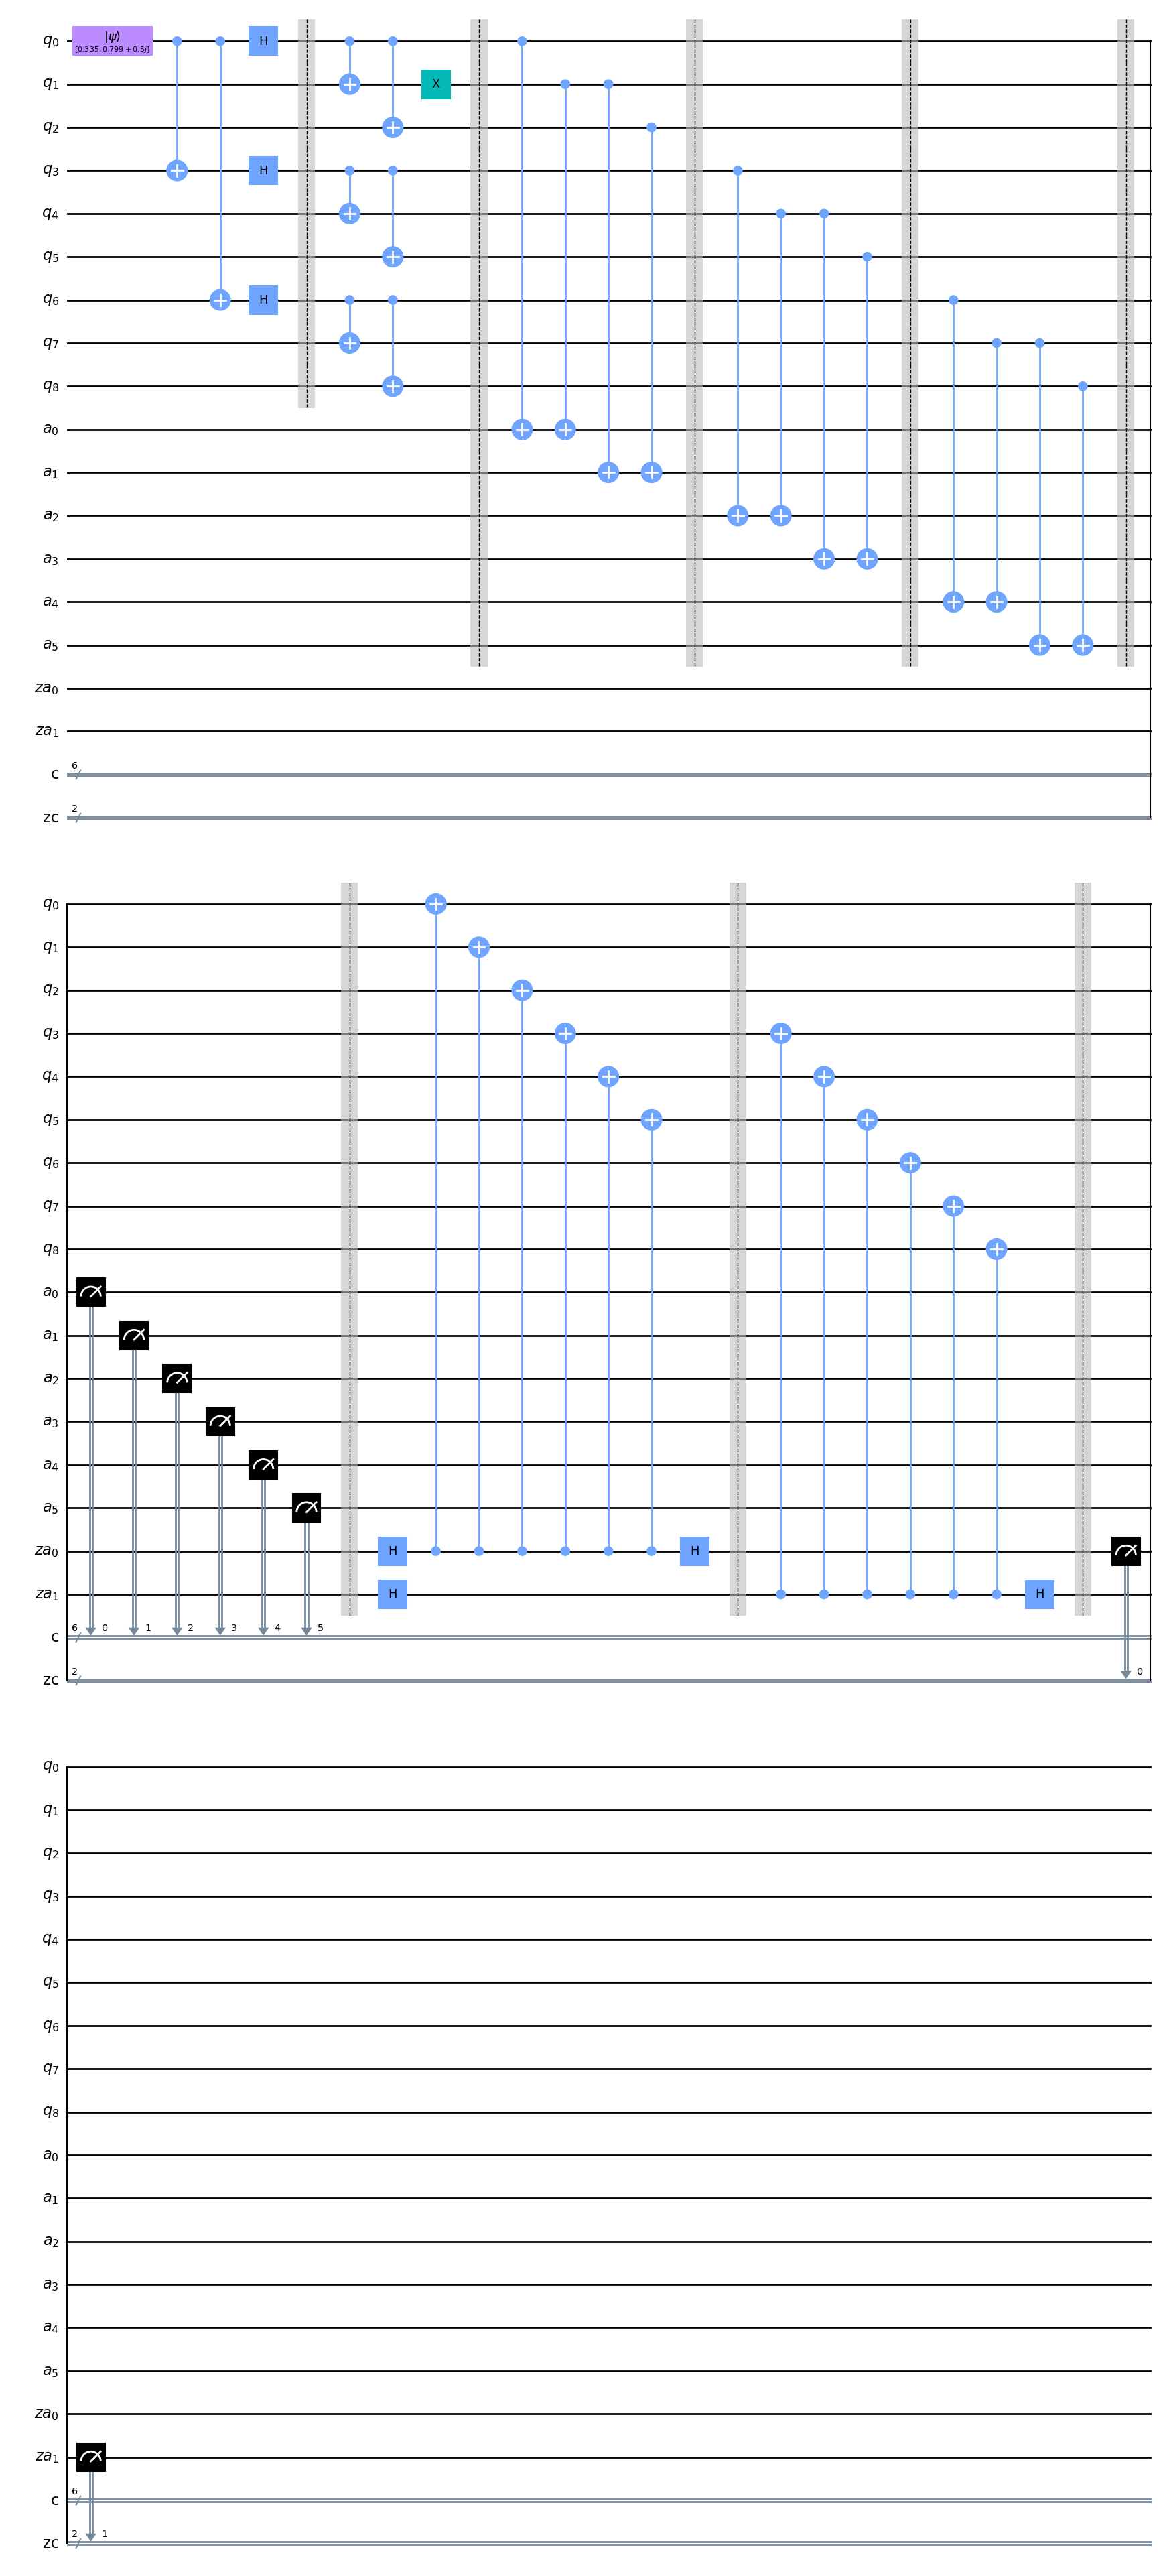

Syndrome for error type X at block 0, position 1, Got: 00 000011
┌─────────┬────────┬──────────────┐
│ Block 0 │  11    │ middle qubit │
│ Block 1 │  00    │ no error     │
│ Block 2 │  00    │ no error     │
│ Z parity│  00    │ no error     │
└─────────┴────────┴──────────────┘
Initial state:
0.401+0.177j |000000000> -0.164-0.177j |111000000> -0.164-0.177j |000111000> + 0.401+0.177j |111111000> -0.164-0.177j |000000111> + 0.401+0.177j |111000111> + 0.401+0.177j |000111111> -0.164-0.177j |111111111>
Data state after correction upto global phase:
0.438 |000000000> -0.222-0.096j |111000000> -0.222-0.096j |000111000> + 0.438 |111111000> -0.222-0.096j |000000111> + 0.438 |111000111> + 0.438 |000111111> -0.222-0.096j |111111111>
Fidelity: 1.0000


──────────────────── Z ERROR ────────────────────



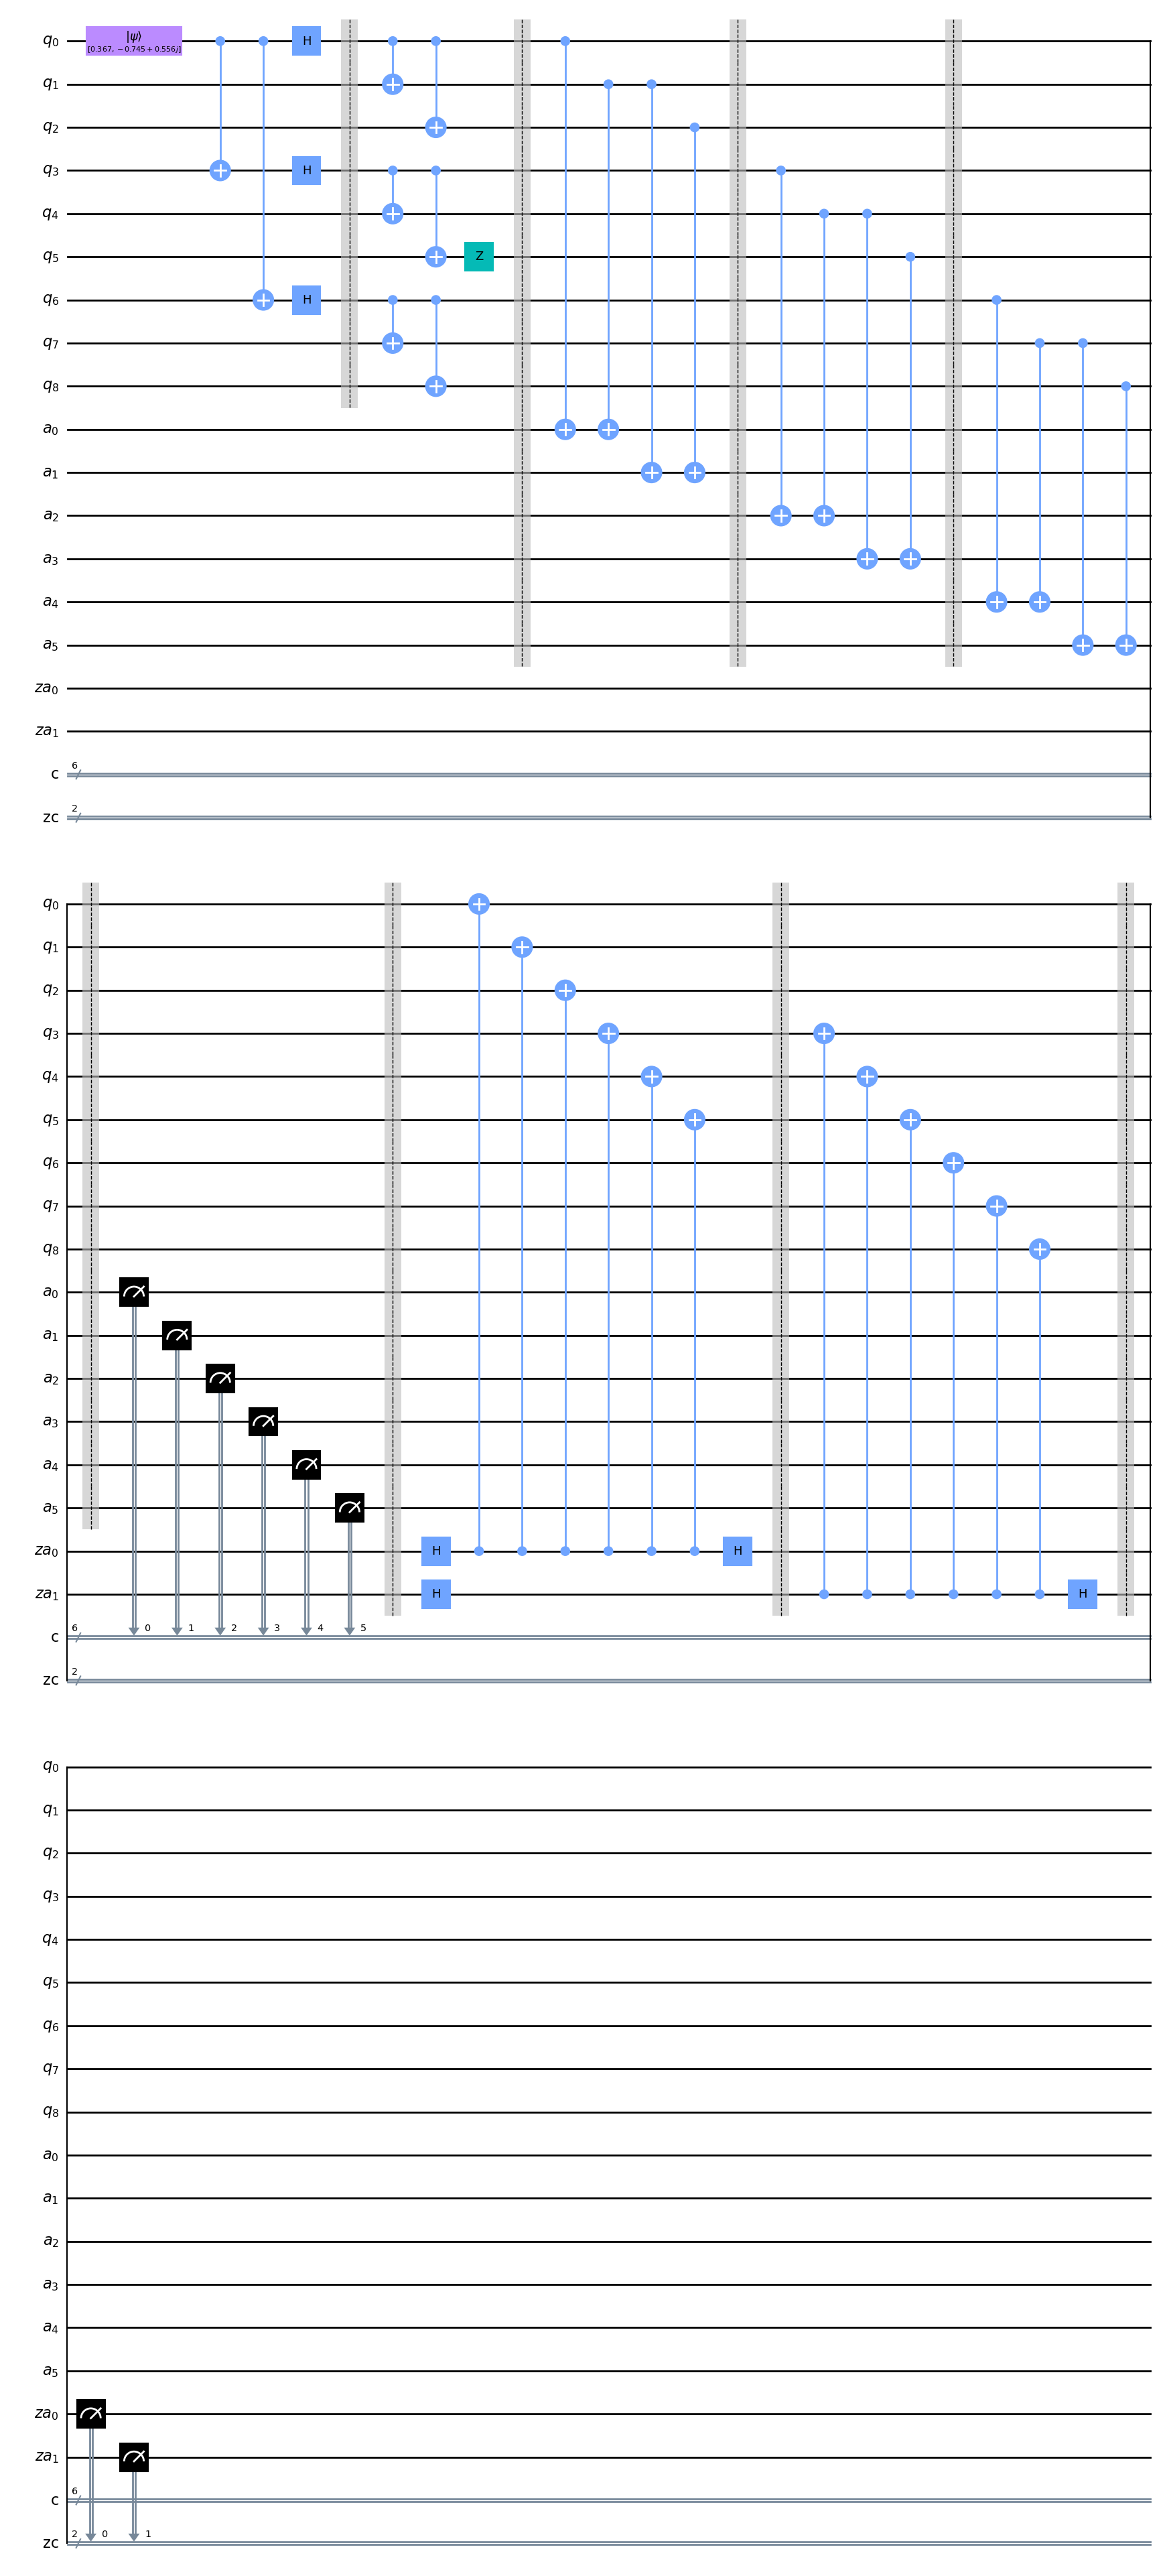

Syndrome for error type Z at block 1, position 2, Got: 11 000000
┌─────────┬────────┬──────────────┐
│ Block 0 │  00    │ no error     │
│ Block 1 │  00    │ no error     │
│ Block 2 │  00    │ no error     │
│ Z parity│  11    │ block 1      │
└─────────┴────────┴──────────────┘
Initial state:
-0.134+0.197j |000000000> + 0.393-0.197j |111000000> + 0.393-0.197j |000111000> -0.134+0.197j |111111000> + 0.393-0.197j |000000111> -0.134+0.197j |111000111> -0.134+0.197j |000111111> + 0.393-0.197j |111111111>
Data state after correction upto global phase:
0.238 |000000000> -0.384-0.215j |111000000> -0.384-0.215j |000111000> + 0.238 |111111000> -0.384-0.215j |000000111> + 0.238 |111000111> + 0.238 |000111111> -0.384-0.215j |111111111>
Fidelity: 1.0000


──────────────────── Y ERROR ────────────────────



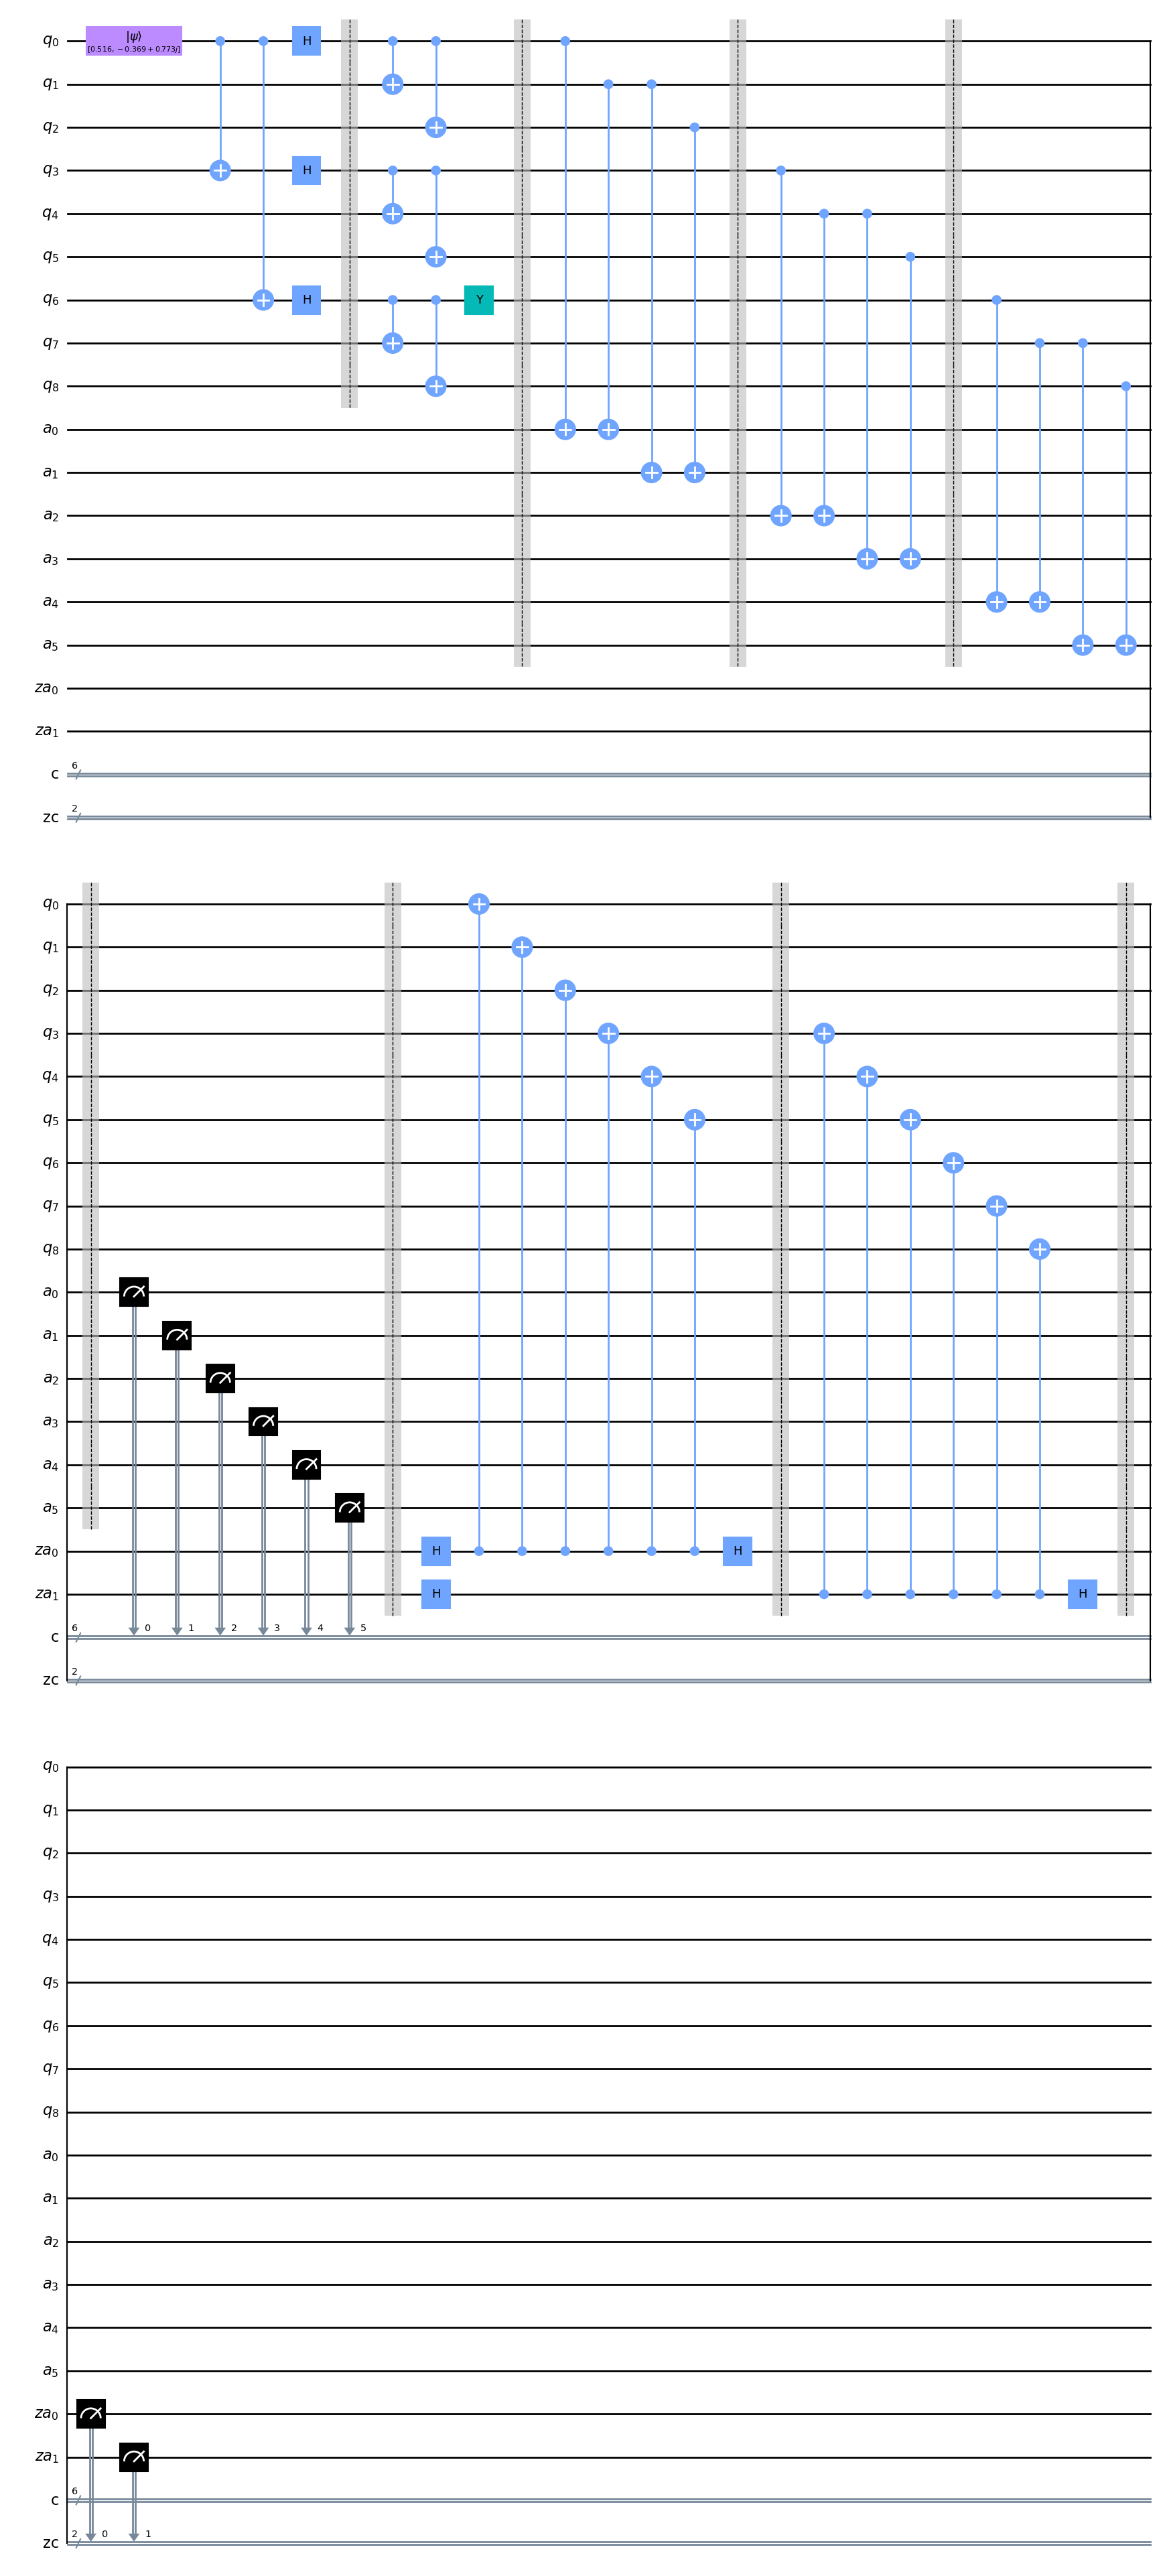

Syndrome for error type Y at block 2, position 0, Got: 10 010000
┌─────────┬────────┬──────────────┐
│ Block 0 │  00    │ no error     │
│ Block 1 │  00    │ no error     │
│ Block 2 │  10    │ left qubit   │
│ Z parity│  01    │ block 2      │
└─────────┴────────┴──────────────┘
Initial state:
0.052+0.273j |000000000> + 0.313-0.273j |111000000> + 0.313-0.273j |000111000> + 0.052+0.273j |111111000> + 0.313-0.273j |000000111> + 0.052+0.273j |111000111> + 0.052+0.273j |000111111> + 0.313-0.273j |111111111>
Data state after correction upto global phase:
0.278 |000000000> -0.21-0.358j |111000000> -0.21-0.358j |000111000> + 0.278 |111111000> -0.21-0.358j |000000111> + 0.278 |111000111> + 0.278 |000111111> -0.21-0.358j |111111111>
Fidelity: 1.0000


In [9]:

def test_error_correction(error_type, error_block, error_position):
    # create arbitrary state |ψ⟩ = α|0⟩ + β|1⟩
    theta = np.random.uniform(0, np.pi)
    phi = np.random.uniform(0, 2 * np.pi)
    alpha = np.cos(theta / 2)
    beta = np.exp(1j*phi) * np.sin(theta / 2)
    # this is of the form |ψ⟩ = cos(θ/2)|0⟩ + e^(iφ)sin(θ/2)|1⟩
    #print(f"|α|² + |β|² = {abs(alpha)**2 + abs(beta)**2:.6f}")  # should be 1.0

    initial_state, data_state = run(alpha, beta, error_block=error_block, error_position=error_position, error_type=error_type)
    print("Initial state:")
    utils.wavefunc(initial_state, precision=3)
    print("==================================")
    print("Data state after correction upto global phase:")
    utils.wavefunc(data_state, precision=3)
    print("==================================")
    fidelity = state_fidelity(initial_state, data_state)
    print(f"Fidelity: {fidelity:.4f}")   # 1.0 = correction worked


print(f"\n\n{'─'*20} X ERROR {'─'*20}\n")
test_error_correction(error_type='X', error_block=0, error_position=1)
print(f"\n\n{'─'*20} Z ERROR {'─'*20}\n")
test_error_correction(error_type='Z', error_block=1, error_position=2)
print(f"\n\n{'─'*20} Y ERROR {'─'*20}\n")
test_error_correction(error_type='Y', error_block=2, error_position=0)
